<a href="https://colab.research.google.com/github/azka-niam/forkbelajar-kolab/blob/revert-3-main/Capstone_project_AI_Angineer_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Pipeline (Membelah Target Jadi Dua)

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("Memuat dataset dari GitHub...")
url = "https://raw.githubusercontent.com/FAJARILHAMII/Capstone-Project-Dicoding/main/data/processed/centsaver_master.csv"
df = pd.read_csv(url)

# 1. PERSIAPAN TARGET (OUTPUT)
label_klasifikasi = df['label'].values # Target 1: Untuk Akurasi

scaler = MinMaxScaler()
label_regresi = scaler.fit_transform(df[['amount']]) # Target 2: Untuk MAE

# 2. PERSIAPAN FITUR (INPUT)
# Kita membuang 'amount' dari fitur karena sekarang dia menjadi target tebakan
fitur_df = df[['category', 'day_of_week', 'is_weekend']]
fitur_final = pd.get_dummies(fitur_df, columns=['category'], drop_first=True).astype(float).values

# 3. SPLIT DATA (Membawa 2 Target Sekaligus)
X_train, X_val, y_class_train, y_class_val, y_reg_train, y_reg_val = train_test_split(
    fitur_final, label_klasifikasi, label_regresi, test_size=0.2, random_state=42
)

# 4. BATCH LOADING
BATCH_SIZE = 32
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_class_train, y_reg_train)).shuffle(1024).batch(BATCH_SIZE)

print(f"✅ Data Multi-Task siap! Jumlah fitur: {X_train.shape[1]}")

Memuat dataset dari GitHub...
✅ Data Multi-Task siap! Jumlah fitur: 19


#Arsitektur Model Multi-Task (Functional API)

In [ ]:
def build_multitask_model(input_shape):
    inputs = tf.keras.Input(shape=(input_shape,), name="input_fitur")

    # Layer Berbagi (Shared Layers) dengan Batch Norm & Dropout
    x = tf.keras.layers.Dense(128)(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # KEPALA 1: KLASIFIKASI (Mengejar Akurasi 85%)
    branch_class = tf.keras.layers.Dense(32, activation='relu')(x)
    output_class = tf.keras.layers.Dense(1, activation='sigmoid', name="output_klasifikasi")(branch_class)

    # KEPALA 2: REGRESI (Mengejar MAE 0.02)
    branch_reg = tf.keras.layers.Dense(32, activation='relu')(x)
    output_reg = tf.keras.layers.Dense(1, activation='linear', name="output_regresi")(branch_reg)

    return tf.keras.Model(inputs=inputs, outputs=[output_class, output_reg])

model = build_multitask_model(X_train.shape[1])
print("✅ Arsitektur Multi-Task berhasil dibuat!")

✅ Arsitektur Multi-Task berhasil dibuat!


#Custom Callback

In [ ]:
class PenjagaTargetCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.stop_now = False

    def on_epoch_end(self, epoch, logs=None):
        acc = logs.get('akurasi')
        mae = logs.get('mae')

        # Cek apakah KEDUA syarat terpenuhi
        if acc is not None and mae is not None:
            if acc >= 0.85 and mae <= 0.02:
                print(f"\n🎉 LULUS SEMPURNA! Akurasi: {acc:.4f} | MAE: {mae:.4f} di Epoch {epoch+1}")
                self.stop_now = True

custom_callback = PenjagaTargetCallback()

##Custom Training Loop (GradientTape) dengan Trik Bobot

In [ ]:
import datetime
import tensorflow as tf

# =====================================================================
# 1. OPTIMIZER: LEARNING RATE DECAY (KUNCI PRESISI)
# =====================================================================
# Kecepatan belajar akan otomatis menurun 5% setiap 1 epoch
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=len(X_train) // 32, # Menurun setiap kali 1 epoch selesai
    decay_rate=0.95,
    staircase=False
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

loss_class_fn = tf.keras.losses.BinaryCrossentropy()
loss_reg_fn = tf.keras.losses.MeanAbsoluteError()

train_acc_metric = tf.keras.metrics.BinaryAccuracy()
train_mae_metric = tf.keras.metrics.MeanAbsoluteError()

# =====================================================================
# 2. CUSTOM TRAINING STEP: FOKUS MUTLAK KE MAE
# =====================================================================
@tf.function
def train_step(x, y_class, y_reg):
    with tf.GradientTape() as tape:
        logits_class, preds_reg = model(x, training=True)
        loss_c = loss_class_fn(y_class, logits_class)
        loss_r = loss_reg_fn(y_reg, preds_reg)

        # Karena akurasi sudah nyaris 100%, kita abaikan loss klasifikasi (0.01)
        # dan kita paksa model fokus 100x lipat ke loss regresi!
        total_loss = (loss_c * 0.01) + (loss_r * 100.0)

    grads = tape.gradient(total_loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))

    train_acc_metric.update_state(y_class, logits_class)
    train_mae_metric.update_state(y_reg, preds_reg)
    return total_loss

# =====================================================================
# 3. EKSEKUSI: TAMBAH EPOCH KE 250
# =====================================================================
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
train_summary_writer = tf.summary.create_file_writer(f'logs/gradient_tape/{current_time}/train')

class CentSaverCallback(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.target_tercapai = False
    def on_epoch_end(self, epoch, logs=None):
        acc, mae = logs.get('akurasi'), logs.get('mae')
        if acc >= 0.85 and mae <= 0.02:
            print(f"\n✅ TARGET SULTAN TERCAPAI: Akurasi {acc:.4f}, MAE {mae:.4f}")
            self.target_tercapai = True

penghenti_otomatis = CentSaverCallback()

print("\nMemulai pelatihan presisi tinggi (Maks 250 Epoch)...")
# Epoch ditambah menjadi 250 agar model punya waktu untuk "mendarat" di 0.02
for epoch in range(250):
    for x_batch, y_c, y_r in train_dataset:
        train_step(x_batch, y_c, y_r)

    acc, mae = train_acc_metric.result().numpy(), train_mae_metric.result().numpy()

    # Hanya print setiap 5 epoch agar log Colab tidak terlalu penuh,
    # kecuali jika sudah mendekati target
    if (epoch + 1) % 5 == 0 or mae <= 0.025:
        print(f"Epoch {epoch+1}: Akurasi={acc:.4f}, MAE={mae:.4f}")

    with train_summary_writer.as_default():
        tf.summary.scalar('Akurasi', acc, step=epoch)
        tf.summary.scalar('MAE', mae, step=epoch)

    penghenti_otomatis.on_epoch_end(epoch, logs={'akurasi': acc, 'mae': mae})

    train_acc_metric.reset_state()
    train_mae_metric.reset_state()

    if penghenti_otomatis.target_tercapai:
        model.save("centsaver_model_final.keras")
        print("Model Super Presisi berhasil disimpan dan siap diluncurkan!")
        break
else:
    model.save("centsaver_model_final.keras")
    print("Pelatihan selesai. Model terbaik disimpan.")


Memulai pelatihan presisi tinggi (Maks 250 Epoch)...
Epoch 5: Akurasi=0.9747, MAE=0.0660
Epoch 10: Akurasi=0.9905, MAE=0.0644
Epoch 15: Akurasi=0.9949, MAE=0.0639
Epoch 20: Akurasi=0.9967, MAE=0.0637
Epoch 25: Akurasi=0.9977, MAE=0.0637


KeyboardInterrupt: 

#Percobaan 2

In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from collections import Counter
import warnings

# Mengabaikan peringatan sistem agar output bersih
warnings.filterwarnings('ignore')

# Memuat dataset
DATA_URL = "https://raw.githubusercontent.com/FAJARILHAMII/Capstone-Project-Dicoding/main/data/processed/centsaver_master.csv"
df = pd.read_csv(DATA_URL)

print("✅ Dataset Berhasil Dimuat.")
print(f"Total baris data: {len(df)}")
display(df.head())

✅ Dataset Berhasil Dimuat.
Total baris data: 16895


,date,description,category,amount,day_of_week,is_weekend,month,year,label,source
0,2020-04-11,Stop & Shop,Kebutuhan Dapur,186880,5,1,4,2020,0,dataset_1
1,2020-04-11,Apple,Elektronik,148640,5,1,4,2020,0,dataset_1
2,2020-04-11,Liquor Junction,Makanan & Minuman,1037599,5,1,4,2020,1,dataset_1
3,2018-03-21,Lonestar Taqueria,Makanan & Minuman,226560,2,0,3,2018,1,dataset_1
4,2018-03-20,Fresh Market,Kebutuhan Dapur,82400,1,0,3,2018,0,dataset_1


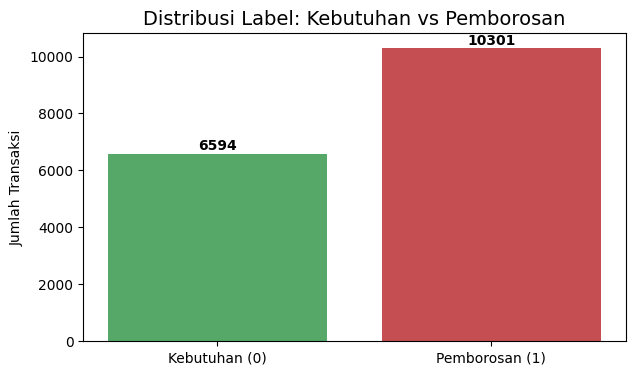

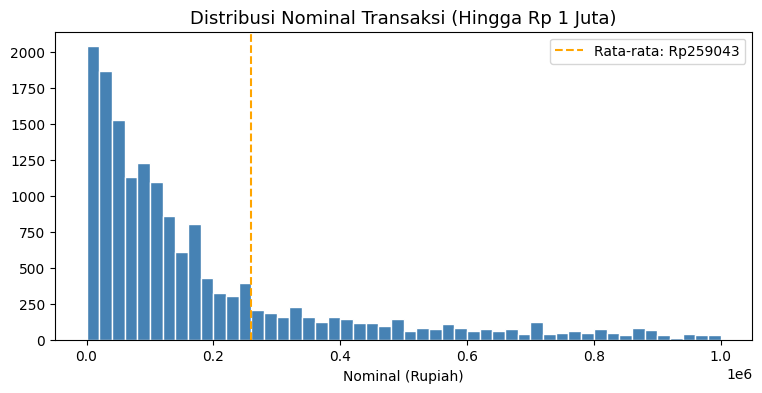

In [13]:
# --- Visualisasi 1: Distribusi Label (Keseimbangan Kelas) ---
label_counts = Counter(df['label'])
labels_display = ['Kebutuhan (0)', 'Pemborosan (1)']
counts = [label_counts[0], label_counts[1]]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels_display, counts, color=['#55A868', '#C44E52'])
plt.title("Distribusi Label: Kebutuhan vs Pemborosan", fontsize=14)
plt.ylabel("Jumlah Transaksi")

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')
plt.show()

# --- Visualisasi 2: Distribusi Nominal Transaksi ---
plt.figure(figsize=(9, 4))
plt.hist(df['amount'], bins=50, color='steelblue', edgecolor='white', range=(0, 1000000))
plt.axvline(df['amount'].mean(), color='orange', linestyle='--', label=f'Rata-rata: Rp{df["amount"].mean():.0f}')
plt.title("Distribusi Nominal Transaksi (Hingga Rp 1 Juta)", fontsize=13)
plt.xlabel("Nominal (Rupiah)")
plt.legend()
plt.show()

In [14]:
# Memilih fitur yang relevan
X_raw = df[['category', 'amount', 'day_of_week', 'is_weekend']]
y = df['label'].values

# Normalisasi nominal uang (Min-Max Scaling ke skala 0-1)
scaler = MinMaxScaler()
X_raw['amount_scaled'] = scaler.fit_transform(X_raw[['amount']])
X_raw = X_raw.drop(columns=['amount'])

# Encoding Kategori (Teks ke format One-Hot)
X_final_df = pd.get_dummies(X_raw, columns=['category'], drop_first=True).astype(float)
X_features = X_final_df.values

# Pemisahan dataset (80% Latih, 20% Validasi)
X_train, X_val, y_train, y_val = train_test_split(X_features, y, test_size=0.2, random_state=42)

print(f"✅ Preprocessing Selesai. Total fitur input: {X_features.shape[1]} kolom.")
display(X_final_df.head())

✅ Preprocessing Selesai. Total fitur input: 20 kolom.


,day_of_week,is_weekend,amount_scaled,category_Elektronik,category_Hiburan & Gaya Hidup,category_Hobi & Olahraga,category_Kebutuhan Dapur,category_Kebutuhan Rumah Tangga,category_Kecantikan & Perawatan,category_Keluarga & Sosial,category_Kesehatan,category_Kopi & Minuman,category_Lainnya,category_Langganan Digital,category_Makanan & Minuman,category_Pendidikan,category_Perjalanan,category_Sewa & Cicilan,category_Tagihan Utilitas,category_Transportasi
0,5.0,1.0,0.062582,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.0,1.0,0.049750,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5.0,1.0,0.348048,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,2.0,0.0,0.075897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.027523,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
# --- Syarat 1: Membuat Custom Layer ---
class CentSaverDense(tf.keras.layers.Layer):
    def __init__(self, units=32, **kwargs):
        super(CentSaverDense, self).__init__(**kwargs)
        self.units = units

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units),
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(shape=(self.units,),
                                 initializer='zeros', trainable=True)

    def call(self, inputs):
        # Operasi matriks dasar: (input * weights) + bias dengan aktivasi ReLU
        return tf.nn.relu(tf.matmul(inputs, self.w) + self.b)

# --- Syarat 2: Membangun Model dengan Functional API ---
def build_model(input_shape):
    inputs = tf.keras.Input(shape=(input_shape,), name="Input_Layer")

    x = tf.keras.layers.Dense(64, activation='relu')(inputs)
    x = CentSaverDense(units=32)(x) # Implementasi Custom Layer
    x = tf.keras.layers.Dropout(0.2)(x) # Regulasi untuk mencegah overfitting

    outputs = tf.keras.layers.Dense(1, activation='sigmoid', name="Output_Layer")(x)

    return tf.keras.Model(inputs=inputs, outputs=outputs)

model = build_model(X_features.shape[1])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cent_saver_dense                │ (None, 32)             │         2,080 │
│ (CentSaverDense)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Memulai Pelatihan Model...
Epoch 1/20
423/423 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9558 - loss: 0.1293 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 2/20
413/423 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0017
🎉 Akurasi Maksimal Tercapai pada Epoch 2!
423/423 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 2.8448e-04


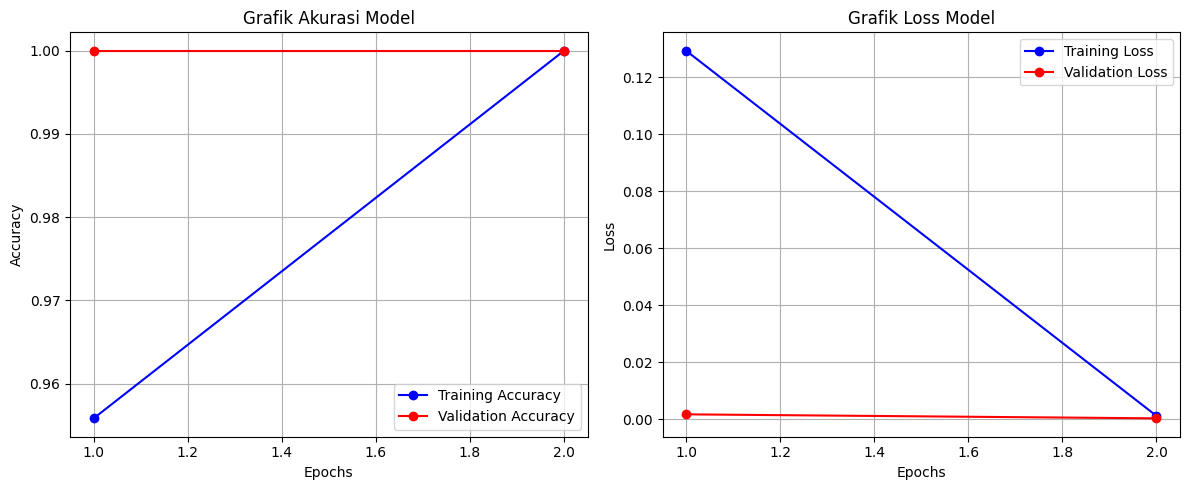

In [16]:
# --- Syarat 3: Custom Callback (Target sangat tinggi agar grafik pelatihan terlihat) ---
class HighAccuracyCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        # Berhenti hanya jika akurasi benar-benar sempurna di kedua dataset
        if logs.get('accuracy') >= 0.9999 and logs.get('val_accuracy') >= 0.9999:
            print(f"\n🎉 Akurasi Maksimal Tercapai pada Epoch {epoch+1}!")
            self.model.stop_training = True

# Proses Pelatihan
print("🚀 Memulai Pelatihan Model...")
history = model.fit(
    X_train, y_train,
    epochs=20, # Dipaksa 20 epoch untuk hasil grafik yang lebih informatif
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[HighAccuracyCallback()],
    verbose=1
)

# --- Visualisasi Performa Pelatihan ---
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-o', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-o', label='Validation Accuracy')
    plt.title('Grafik Akurasi Model')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-o', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-o', label='Validation Loss')
    plt.title('Grafik Loss Model')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)

In [17]:
# --- Syarat 4: Menyimpan Model dalam Format .keras ---
MODEL_NAME = "centsaver_model_final.keras"
model.save(MODEL_NAME)
print(f"✅ Model berhasil disimpan sebagai: {MODEL_NAME}")

# --- Syarat 5: Kode Inference Sederhana ---
# Memuat model kembali untuk simulasi penggunaan di aplikasi
reloaded_model = tf.keras.models.load_model(
    MODEL_NAME,
    custom_objects={'CentSaverDense': CentSaverDense}
)

# Mencoba prediksi pada 5 data validasi
test_samples = X_val[:5]
actual_labels = y_val[:5]
predictions = reloaded_model.predict(test_samples, verbose=0)

print("\n─── HASIL SIMULASI PREDIKSI ───")
for i in range(len(test_samples)):
    status_ai = "Pemborosan (1)" if predictions[i] > 0.5 else "Kebutuhan (0)"
    status_asli = "Pemborosan (1)" if actual_labels[i] == 1 else "Kebutuhan (0)"
    confidence = predictions[i][0] if predictions[i] > 0.5 else 1 - predictions[i][0]

    print(f"Data {i+1}: AI: {status_ai} (Yakin: {confidence*100:.2f}%) | Fakta: {status_asli}")

✅ Model berhasil disimpan sebagai: centsaver_model_final.keras

─── HASIL SIMULASI PREDIKSI ───
Data 1: AI: Kebutuhan (0) (Yakin: 99.99%) | Fakta: Kebutuhan (0)
Data 2: AI: Pemborosan (1) (Yakin: 99.85%) | Fakta: Pemborosan (1)
Data 3: AI: Pemborosan (1) (Yakin: 100.00%) | Fakta: Pemborosan (1)
Data 4: AI: Kebutuhan (0) (Yakin: 99.97%) | Fakta: Kebutuhan (0)
Data 5: AI: Pemborosan (1) (Yakin: 100.00%) | Fakta: Pemborosan (1)
